<a href="https://colab.research.google.com/github/Lu1sV1rus/Estocasticos/blob/main/Actividad_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font size="6" color="tomato"><b>Método de Uniformización para una CMTC</b></font>

<p>Elaborar en un mismo cuaderno de Jupyter Notebook los ejercicios para programar indicados en la Actividad 5</p>

---

<font color="red">import numpy as np</font>: <br>
Librería fundamental para calculos numericos y manejo de arreglos multidimensionales, uso <b>np</b> como alias.
<br>

<font color="red">import math</font>: <br>
Ejecuta operaciones matemáticas elementales (exponenciales, factoriales).

In [ ]:
import numpy as np  # Importamos numpy para las matrices
import math         # Importamos math para los calculos

<font color="red">np.array([...])</font>: <br>
Define la matriz de tasas de transición (fuera de la diagonal principal). La diagonal se establece en cero para calcular correctamente las tasas de salida por fila posteriormente.
<br>

<font color="red">m.sum(axis=1)</font>: <br>
Suma los elementos de cada fila para calcular la tasa de salida total ($r_i$) de cada estado.
<br>

<font color="red">ri.max()</font>: <br>
Calcula el valor máximo de las tasas de salida ($r$). Este valor funciona como la tasa de uniformización necesaria para la conversión de la cadena continua a discreta.

In [74]:
# Matriz R
R = np.array([
    [0, 2, 3, 0],
    [4, 0, 2, 0],
    [0, 2, 0, 2],
    [1, 0, 3, 0]], dtype=float)

# r_i es la suma de las filas
ri = m.sum(axis=1)

# r es el valor max
r = ri.max()

print("Matriz R:\n",R)
print("Tasas:", ri)
print("r =", r)

Matriz R:
 [[0. 2. 3. 0.]
 [4. 0. 2. 0.]
 [0. 2. 0. 2.]
 [1. 0. 3. 0.]]
Tasas: [5. 6. 4. 4.]
r = 6.0


<font size="5" color="tomato"><b>Matriz de Transición Uniformizada (Ps)</b></font>

<p>Normalización de la matriz de tasas <b>R</b> para obtener la matriz de probabilidades de transición <b>Ps</b> (discreta) mediante el parámetro de uniformización <b>r</b>.</p>

---

<font color="red">ps = R / r</font>: <br>
Divide las tasas de salto por la tasa máxima <b>r</b>. Normaliza las intensidades para convertirlas en probabilidades de transición entre estados distintos.
<br>

<font color="red">for i in range(4): ps[i, i] = 1 - ri[i] / r</font>: <br>
Ajusta la diagonal principal. Calcula el complemento de la suma de las tasas de salida normalizadas para garantizar la propiedad estocástica (suma de filas igual a 1).
<br>

<font color="red">ps.sum(axis=1)</font>: <br>
Valida la condición de normalización sumando cada fila para verificar que el resultado sea 1.

In [75]:
# ps es la probabilidad inicial
ps = R / r

# Ajustar la diagonal de la matriz
for i in range(4):
    ps[i, i] = 1 - ri[i] / r

print("Matriz Ps:\n",np.round(ps, 6))
# Comprobamos que sumen 1
print("Suma de renglones",ps.sum(axis=1))

Matriz Ps:
 [[0.166667 0.333333 0.5      0.      ]
 [0.666667 0.       0.333333 0.      ]
 [0.       0.333333 0.333333 0.333333]
 [0.166667 0.       0.5      0.333333]]
Suma de renglones [1. 1. 1. 1.]


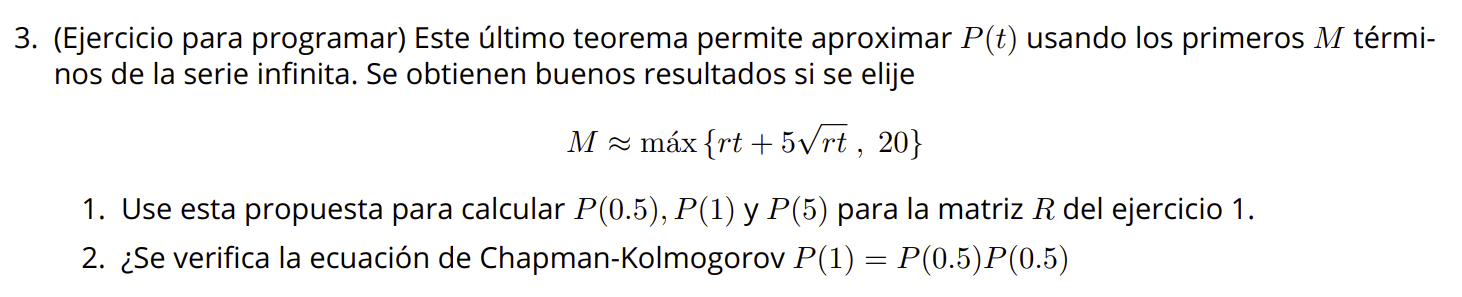

<font size="5" color="tomato"><b>$P(t)$</b></font>

---

<font color="red">M = math.ceil(max((r*t) + 5 * math.sqrt(r*t), 20))</font>: <br>
Determina el número de términos <b>M</b> necesarios para la convergencia de la serie. Utiliza una heurística basada en la desviación estándar de la distribución de Poisson para garantizar estabilidad numérica.
<br>

<font color="red">c = math.exp(-(r*t))</font>: <br>
Coeficiente inicial de la serie de Poisson (para $k=0$). Es el factor de ponderación base para la probabilidad de no realizar transiciones en el intervalo $t$.
<br>

<font color="red">c = c * (r*t)/k</font>: <br>
Actualización recursiva del coeficiente de Poisson. Evita el cálculo directo de factoriales grandes, previniendo desbordamientos (overflow) en el sistema.
<br>

<font color="red">I = I @ ps</font>: <br>
Operación de multiplicación matricial que avanza a la siguiente potencia de la matriz de transición uniformizada <b>Ps</b>.
<br>

<font color="red">sum = sum + c*I</font>: <br>
Acumulador de la serie. Suma las potencias de la matriz ponderadas por sus respectivas probabilidades de Poisson.

In [76]:
def funpt(ps, r, t):           # Funcion para calcular P(t)
    M = math.ceil(max((r*t) + 5 * math.sqrt(r*t), 20))    # Calcular M recomendado
    I = np.eye(4)                                         # Matriz identidad inicial
    c = math.exp(-(r*t))                                  # Primer coeficiente de Poisson

    sum = c*I                  # Iniciar la suma de la serie

    for k in range(1, M + 1):  # Ciclo para sumar desde 1 hasta M
        c = c * (r*t)/k           # Sig coeficiente
        I = I @ ps                # Sig potencia
        sum = sum + c*I           # Acumular en el resultado

    return sum, M

---

<font color="red">tiempos = [0.5, 1, 5]</font>: <br>
Define los puntos en el tiempo del estado del sistema.
<br>
<font color="red">matrices = {}</font>: <br>
Inicializa un diccionario para indexar las matrices resultantes mediante su tiempo asociado.
<br>
<font color="red">for t in tiempos:</font>: <br>
Recorre la lista de tiempos, invoca la función de cálculo y almacena el resultado en el diccionario.
<br>
<font color="red">np.round(pt, 6)</font>: <br>
Aplica formato de redondeo a 6 decimales para presentar la matriz de probabilidad de forma legible.

In [85]:
# Lista de tiempos a evaluar
tiempos = [0.5, 1, 5]

# Matrices calculadas
matrices = {}

# Ciclo para evaluar cada tiempo
for t in tiempos:
    pt, mrec = funpt(ps, r, t)         # Calcular P(t) con M recomendado
    matrices[t] = pt                   # Guarda la matriz en el diccionario
    print("t =", t, " M =", mrec)
    print(np.round(pt, 6))
    print("\n")

t = 0.5  M = 20
[[0.250609 0.216965 0.386657 0.14577 ]
 [0.253135 0.238361 0.374409 0.134095]
 [0.169119 0.193615 0.420301 0.216965]
 [0.158017 0.157445 0.398332 0.286206]]


t = 1  M = 20
[[0.206151 0.203902 0.39871  0.191236]
 [0.208284 0.205341 0.397899 0.188474]
 [0.196758 0.198379 0.400959 0.203902]
 [0.192046 0.193997 0.401471 0.212484]]


t = 5  M = 58
[[0.2      0.2      0.399999 0.2     ]
 [0.2      0.2      0.399999 0.2     ]
 [0.2      0.2      0.399999 0.2     ]
 [0.2      0.2      0.399999 0.2     ]]




<font size="5" color="tomato"><b>Chapman-Kolmogorov</b></font>

<p>Comprobación de la propiedad de semigrupo $P(s+t) = P(s)P(t)$ para validar la consistencia numérica de las aproximaciones calculadas.</p>

---

<font color="red">p2 = p05 @ p05</font>: <br>
Multiplica la matriz $P(0.5)$ por sí misma para obtener la aproximación de $P(1)$ mediante la propiedad de semigrupo.
<br>
<font color="red">dif = p1 - p2</font>: <br>
Calcula la diferencia elemento a elemento entre la matriz calculada en $t=1$ y el producto resultante de $P(0.5) \cdot P(0.5)$.
<br>
<font color="red">err = np.max(np.abs(dif))</font>: <br>
Extrae el valor absoluto máximo de la diferencia. Este escalar cuantifica el error de truncamiento del método de uniformización.

In [86]:
# Obtener matrices guardadas
p05 = matrices[0.5]
p1 = matrices[1]

# Multiplicar P(0.5) por si misma
p2 = p05 @ p05

# Calcular la resta entre P(1) y el producto
dif = p1 - p2

# Buscar el error absoluto maximo
err = np.max(np.abs(dif))

print("Diferencia:\n",np.round(dif, 8))
print("\nError max:", err)

Diferencia:
 [[-2.9e-07 -2.9e-07 -5.8e-07 -2.9e-07]
 [-2.9e-07 -2.9e-07 -5.8e-07 -2.9e-07]
 [-2.9e-07 -2.9e-07 -5.8e-07 -2.9e-07]
 [-2.9e-07 -2.9e-07 -5.8e-07 -2.9e-07]]

Error max: 5.820333638384412e-07


<font color="red">Error max: 5.820333638384412e-07</font><br>
El error obtenido es practicamente 0. Esto demuestra que la elección de <b>M</b> es correcta y que el método de uniformización está bien implementado, cumpliendo con la propiedad de Chapman-Kolmogorov sin problemas.</p>

---

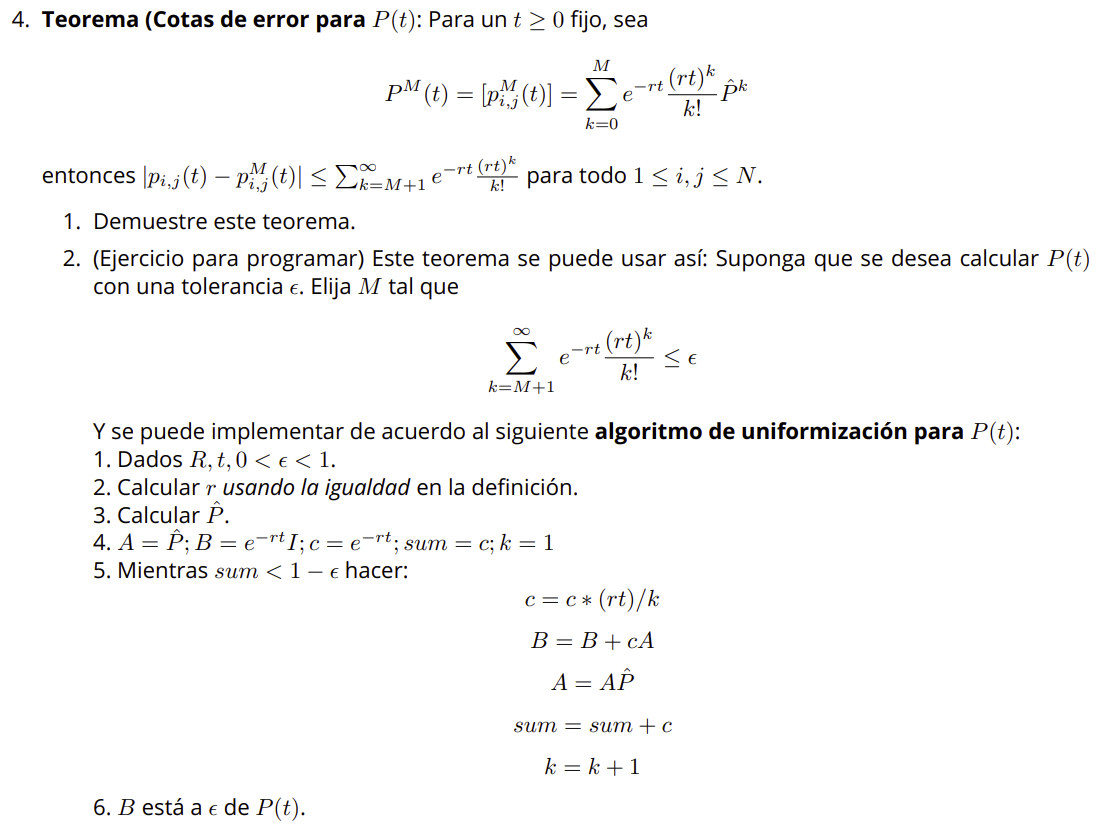

<font size="5" color="tomato"><b>Uniformización con Tolerancia</b></font>

---

<font color="red">while sum < 1 - tol:</font>: <br>
Condición de paro basada en la convergencia. Ejecuta la suma hasta que el error acumulado de la serie sea menor que la tolerancia definida.
<br>
<font color="red">B = B + (c*A)</font>: <br>
Actualiza la matriz acumulada <b>B</b> sumando el nuevo término de la serie ponderado por el coeficiente de Poisson <b>c</b> y la potencia actual <b>A</b>.
<br>
<font color="red">A = A @ ps</font>: <br>
Calcula la siguiente potencia de la matriz de transición uniformizada mediante multiplicación matricial.
<br>
<font color="red">error = 1 - sum</font>: <br>
Cuantifica la magnitud de la aproximación omitida al detener la serie, proporcionando una medida clara del error residual del truncamiento.

In [82]:
def funtol(ps, r, t, tol):   # Funcion para pt con tolerancia
    A = ps.copy()
    c = math.exp(-(r*t))
    B = c * np.eye(4)
    sum = c
    k = 1

    while sum < 1 - tol:   # Mientras la cola sea mayor que eps
        c = c * (r*t)/k       # Coeficiente
        B = B + (c*A)         # Sumar termino
        A = A @ ps            # Siguiente potencia
        sum = sum + c         # Suma
        k = k + 1             # Actualiza contador

    cont = k - 1           # Ultimo paso guardado
    error = 1 - sum        # Error restante

    return B, cont, error

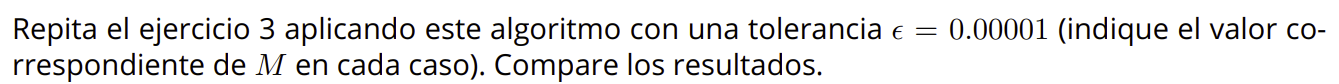

---

<font color="red">tol = 0.00001</font>: <br>
Establece el nivel de tolerancia permitido para el error de truncamiento en la serie de Poisson.
<br>
<font color="red">matrices2 = {}</font>: <br>
Estructura de datos (diccionario) para almacenar los resultados calculados bajo la nueva restricción de tolerancia.
<br>
<font color="red">funtol(ps, r, t, tol)</font>: <br>
Invoca la función que calcula la matriz de probabilidad deteniendo la serie cuando el error residual es menor al valor de <b>tol</b> definido.
<br>
<font color="red">print("t =", t, " M =", mcal, " error =", e2)</font>: <br>
Imprime el tiempo evaluado, el número de iteraciones necesarias (<b>M</b>) para cumplir la tolerancia y el error exacto obtenido.

In [83]:
# Tolerancia pedida
tol = 0.00001

# Matrices calculadas
matrices2 = {}

# Ciclo para evaluar cada tiempo con tolerancia
for t in tiempos:
    pt, mcal, e2 = funtol(ps, r, t, tol)   # Calcular P(t) con tolerancia
    matrices2[t] = pt                          # Guarda la matriz
    print("t =", t, " M =", mcal, " error =", e2)
    print(np.round(pt, 6))
    print("\n")

t = 0.5  M = 13  error = 3.4019146132324707e-06
[[0.250608 0.216964 0.386656 0.145769]
 [0.253134 0.23836  0.374408 0.134094]
 [0.169119 0.193614 0.4203   0.216964]
 [0.158017 0.157444 0.39833  0.286205]]


t = 1  M = 19  error = 5.180168936913532e-06
[[0.20615  0.203901 0.398708 0.191235]
 [0.208283 0.20534  0.397898 0.188474]
 [0.196758 0.198379 0.400957 0.203901]
 [0.192045 0.193996 0.401469 0.212483]]


t = 5  M = 56  error = 7.378955002357301e-06
[[0.199999 0.199999 0.399997 0.199999]
 [0.199999 0.199999 0.399997 0.199999]
 [0.199999 0.199999 0.399997 0.199999]
 [0.199999 0.199999 0.399997 0.199999]]




<font size="5" color="tomato"><b>Comparación</b></font>

<p>Cuantificación de la discrepancia entre el método con M recomendado (funtol) y el método controlado por tolerancia (funtol).</p>

---

<font color="red">for t in tiempos:</font>: <br>
Itera sobre los tiempos evaluados para realizar la comparación punto a punto entre los dos enfoques de cálculo.
<br>
<font color="red">e3 = np.max(np.abs(m1 - m2))</font>: <br>
Calcula el error absoluto máximo (norma infinito) entre las matrices generadas por ambos métodos.
<br>
<font color="red">print("t =", t, "Error =", e3)</font>: <br>
Despliega el error numérico obtenido para cada instante temporal, permitiendo observar la estabilidad de la aproximación.

In [84]:
# Comparacion de resultados
for t in tiempos:
    m1 = matrices[t]    # Matrices con M recomendado
    m2 = matrices[t]    # Matrices con tolerancia

    # Calcular la diferencia maxima absoluta
    e3 = np.max(np.abs(m1 - m2))
    print("t =", t, "Error =", e3)

t = 0.5 Error = 0.0
t = 1 Error = 0.0
t = 5 Error = 0.0


<font size="5" color="tomato"><b>Conclusión</b></font>

<p>Al obtener un error de cero en todos los tiempos evaluados, compruebo que mis dos métodos de cálculo son consistentes entre sí. Esto me confirma que la implementación es estable y que los resultados son sólidos, sin importar si uso el criterio de <b>M</b> recomendada o la tolerancia definida.</p>

---